In [1]:
#Імпорти, неймспейси та типи даних
from rdflib import Graph, Literal, Namespace, RDF

g = Graph()
GAME = Namespace("http://example.org/gamedb/")
SCHEMA = Namespace("https://schema.org/")

g.bind("game", GAME)
g.bind("schema", SCHEMA)

entity_types = {
    "Game": GAME.Game,
    "Developer": GAME.Developer,
    "Genre": GAME.Genre,
    "Publisher": GAME.Publisher,
    "Platform": GAME.Platform,
}

In [2]:
#Сутності не ігри
developers = [
    (GAME.dev_gsc_game_world, "GSC Game World", GAME.pub_gsc),
    (GAME.dev_cd_projekt_red, "CD Projekt Red", GAME.pub_cdpr),
    (GAME.dev_the_indie_stone, "The Indie Stone", GAME.pub_the_indie_stone),
    (GAME.dev_4a_games, "4A Games", GAME.pub_deep_silver)
]

publishers = [
    (GAME.pub_gsc, "GSC World Publishing"),
    (GAME.pub_cdpr, "CD Projekt"),
    (GAME.pub_the_indie_stone, "The Indie Stone"),
    (GAME.pub_deep_silver, "Deep Silver")
]
genres = [GAME.genre_fps,
          GAME.genre_rpg,
          GAME.genre_survival_horror]
platforms = [GAME.platform_pc,
             GAME.platform_ps4,
             GAME.platform_ps5,
             GAME.platform_xbox,
             GAME.platform_switch]

In [3]:
#Сутності ігри
games = [
    (GAME.game_stalker_2, "S.T.A.L.K.E.R. 2: Heart of Chornobyl",
     GAME.dev_gsc_game_world, GAME.pub_gsc, GAME.genre_fps, GAME.platform_pc),
    (GAME.game_witcher3, "The Witcher 3: Wild Hunt",
     GAME.dev_cd_projekt_red, GAME.pub_cdpr, GAME.genre_rpg, GAME.platform_switch),
    (GAME.game_stalker_sc, "S.T.A.L.K.E.R.: Shadow of Chernobyl",
     GAME.dev_gsc_game_world, GAME.pub_gsc, GAME.genre_fps, GAME.platform_ps4),
    (GAME.game_metro_2033, "Metro 2033 Redux",
     GAME.dev_4a_games, GAME.pub_deep_silver, GAME.genre_survival_horror, GAME.platform_xbox),
    (GAME.game_project_zomboid, "Project Zomboid",
     GAME.dev_the_indie_stone, GAME.pub_the_indie_stone, GAME.genre_survival_horror, GAME.platform_pc),
]

In [4]:
#Наповнення графа за допомогою циклів
for g_uri, title, dev, pub, genre, plat in games:
    g.add((g_uri, RDF.type, GAME.Game))
    g.add((g_uri, SCHEMA.name, Literal(title)))
    g.add((g_uri, GAME.developedBy, dev))
    g.add((g_uri, GAME.hasGenre, genre))
    g.add((g_uri, GAME.availableOn, plat))

for dev, name, pub in developers:
    g.add((dev, RDF.type, GAME.Developer))
    g.add((dev, SCHEMA.name, Literal(name)))
    g.add((dev, GAME.partneredWith, pub))

for pub, name in publishers:
    g.add((pub, RDF.type, GAME.Publisher))
    g.add((pub, SCHEMA.name, Literal(name)))

for genre in genres:
    g.add((genre, RDF.type, GAME.Genre))

for plat in platforms:
    g.add((plat, RDF.type, GAME.Platform))
print(f"Всього трійок: {len(g)}")


Всього трійок: 53


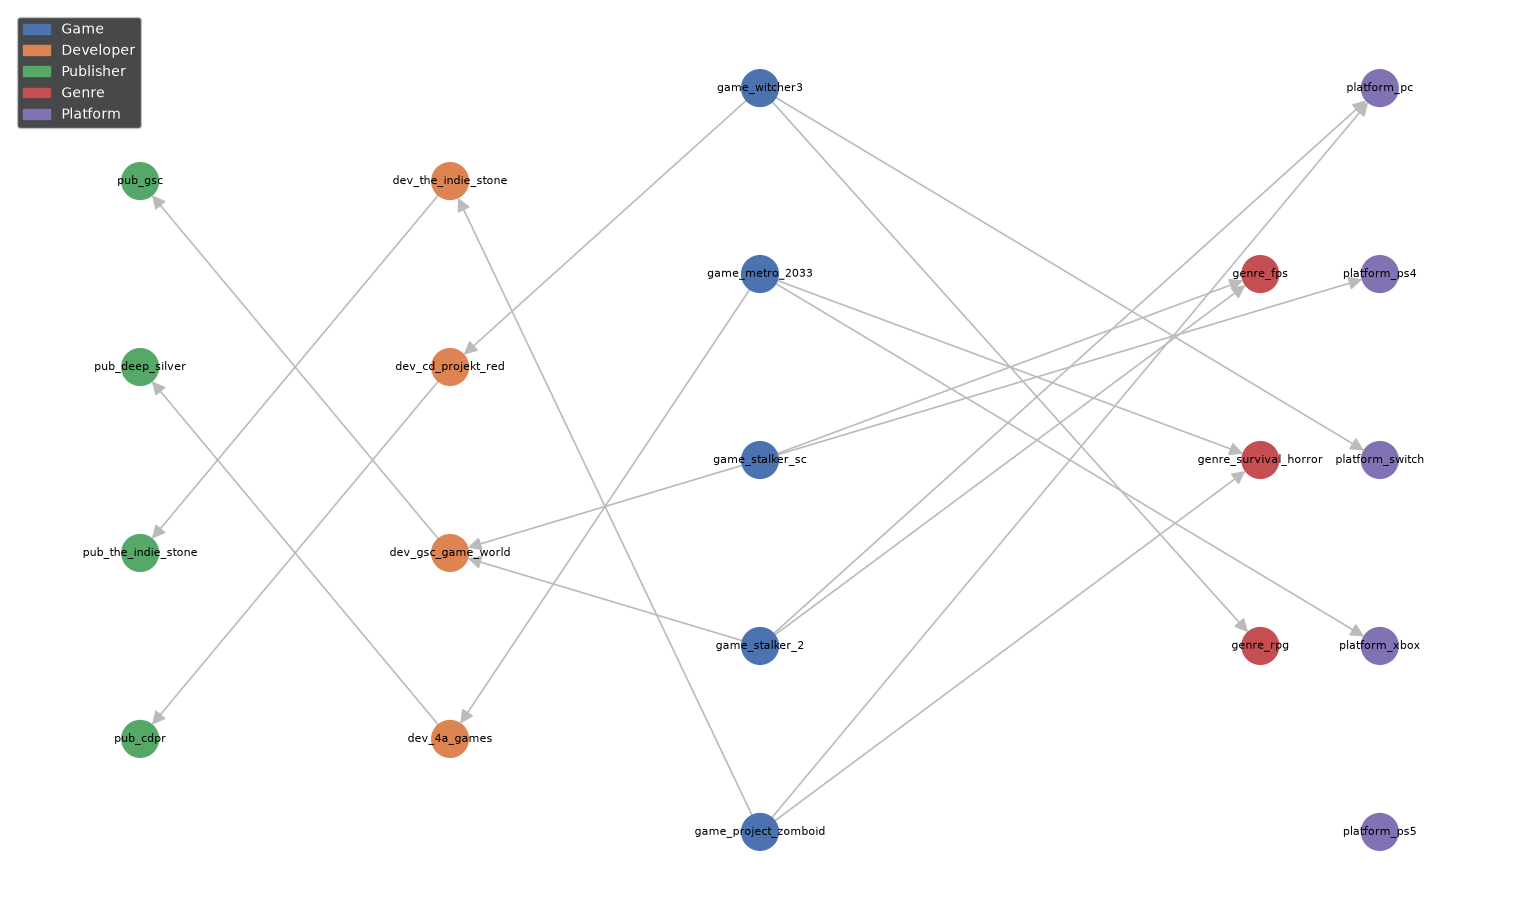

In [5]:
import networkx as nx, matplotlib.pyplot as plt, matplotlib.patches as mpatches
from rdflib import RDF, URIRef

G = nx.DiGraph()
for s, p, o in g:
    if p == RDF.type:
        G.add_node(str(s), t=str(o).split('/')[-1])
    elif isinstance(o, URIRef) and str(o).startswith(str(GAME)):
        G.add_edge(str(s), str(o))

order = ['Publisher', 'Developer', 'Game', 'Genre', 'Platform']
for n in G:
    G.nodes[n]['layer'] = order.index(G.nodes[n]['t'])

colors = {'Game':'#4C72B0','Developer':'#DD8452','Publisher':'#55A868','Genre':'#C44E52','Platform':'#8172B3'}
plt.figure(figsize=(15, 9))
pos = nx.multipartite_layout(G, subset_key='layer', align='vertical')
shift = 0.3
for n in G:
    if G.nodes[n]['t'] == 'Genre':
        x, y = pos[n]
        pos[n] = (x + shift, y)
nx.draw(G, pos, with_labels=True, labels={n: n.split('/')[-1] for n in G},
        node_color=[colors[G.nodes[n]['t']] for n in G],
        node_size=700, font_size=8, edge_color='#bbb', width=1.2, arrows=True, arrowstyle='-|>', arrowsize=20)
plt.legend(handles=[mpatches.Patch(color=c, label=t) for t, c in colors.items()], loc='upper left')
plt.axis('off')
plt.savefig("graph.png")
plt.show()

In [6]:
# Серіалізуємо у Turtle та Rdf
output_file = "games_graph.ttl"
g.serialize(destination=output_file, format="turtle")
g.serialize(destination="games_graph.rdf", format="xml")

<Graph identifier=N9a322d40c17840488327906a5d677bda (<class 'rdflib.graph.Graph'>)>

In [7]:
#Зчитуємо та виводимо трійки певної гри
g_view = Graph()
g_view.parse(output_file, format="turtle")
print("Трійки доступності на платформах:")
for s,p,o in g_view.triples((None, GAME.availableOn, None)):
    print(f'{s}\t{p}\t{o}')
print("Трійки гри Project Zomboid:")
for s,p,o in g_view.triples((GAME.game_project_zomboid, None, None)):
        print(f'{s}\t{p}\t{o}')

# https://www.wikidata.org/wiki/Q215861
# https://www.wikidata.org/wiki/Q19906377


Трійки доступності на платформах:
http://example.org/gamedb/game_metro_2033	http://example.org/gamedb/availableOn	http://example.org/gamedb/platform_xbox
http://example.org/gamedb/game_project_zomboid	http://example.org/gamedb/availableOn	http://example.org/gamedb/platform_pc
http://example.org/gamedb/game_stalker_2	http://example.org/gamedb/availableOn	http://example.org/gamedb/platform_pc
http://example.org/gamedb/game_stalker_sc	http://example.org/gamedb/availableOn	http://example.org/gamedb/platform_ps4
http://example.org/gamedb/game_witcher3	http://example.org/gamedb/availableOn	http://example.org/gamedb/platform_switch
Трійки гри Project Zomboid:
http://example.org/gamedb/game_project_zomboid	http://www.w3.org/1999/02/22-rdf-syntax-ns#type	http://example.org/gamedb/Game
http://example.org/gamedb/game_project_zomboid	http://example.org/gamedb/availableOn	http://example.org/gamedb/platform_pc
http://example.org/gamedb/game_project_zomboid	http://example.org/gamedb/developedBy	http:

In [8]:
from rdflib import URIRef
from rdflib.namespace import OWL

g.bind("owl", OWL)
g.add((
    GAME.game_stalker_sc,
    OWL.sameAs,
    URIRef("http://www.wikidata.org/entity/Q215861")
))
g.add((
    GAME.game_metro_2033,
    OWL.sameAs,
    URIRef("http://www.wikidata.org/entity/Q92203899")
))

<Graph identifier=N9a322d40c17840488327906a5d677bda (<class 'rdflib.graph.Graph'>)>

In [9]:
fed_q= """
PREFIX game: <http://example.org/gamedb/>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX schema: <https://schema.org/>

SELECT ?localTitle ?wikidataLabel ?pubDate
WHERE {
  ?game schema:name ?localTitle ;
        owl:sameAs ?wdEntity .

SERVICE <https://query.wikidata.org/sparql> {
    OPTIONAL { ?wdEntity rdfs:label ?wikidataLabel . FILTER(LANG(?wikidataLabel) = "en") }
    OPTIONAL { ?wdEntity wdt:P577 ?pubDate . }
  }
}
"""
for r in g.query(fed_q):
    print(r)

rdflib.term.URIRef('http://www.wikidata.org/entity/Q92203899')
(rdflib.term.Literal('S.T.A.L.K.E.R.: Shadow of Chernobyl'), rdflib.term.Literal('S.T.A.L.K.E.R.: Shadow of Chernobyl', lang='en'), rdflib.term.Literal('2007-03-20T00:00:00+00:00', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#dateTime')))
(rdflib.term.Literal('Metro 2033 Redux'), rdflib.term.Literal('Metro 2033 Redux', lang='en'), rdflib.term.Literal('2014-08-27T00:00:00+00:00', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#dateTime')))
